# GC=F Risk & macro dashboard for leveraged CFD trading

## Python structure and packages
Basic packages and overall notebook structure

In [99]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
plt.style.use("seaborn-v0_8-darkgrid")

# --- Institutional styling ---
plt.style.use("seaborn-v0_8-muted")
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.facecolor": "#f8f9fa",
    "grid.color": "#e9ecef",
    "figure.figsize": (16, 10)
})

class GSChartingStandards:
    COLORS = {
        'real': '#1f77b4',           # Blue (real data)
        'synthetic': '#ff7f0e',      # Orange (synthetic data)
        'pass': '#2ca02c',           # Green (pass threshold)
        'fail': '#d62728',           # Red (fail threshold)
        'caution': '#ff9800',        # Amber (caution zone)
        'neutral': '#7f7f7f',        # Gray (neutral)
        'highlight': '#1f77b4'       # Highlight blue
    }
    
    FONT_SIZE = {
        'title': 14,
        'label': 11,
        'tick': 10,
        'legend': 10,
        'annotation': 9
    }
    
    FIGURE_DPI = 300  
    FIGURE_FORMAT = 'png'
    
    @staticmethod
    def configure():
        """Apply GS charting standards to matplotlib session"""
        sns.set_style("darkgrid")
        sns.set_palette("husl")
        
        plt.rcParams.update({
            'font.family': 'sans-serif',
            'font.sans-serif': ['Arial', 'Helvetica'],
            'font.size': GSChartingStandards.FONT_SIZE['label'],
            'axes.labelsize': GSChartingStandards.FONT_SIZE['label'],
            'axes.titlesize': GSChartingStandards.FONT_SIZE['title'],
            'axes.labelweight': 'bold',
            'axes.titleweight': 'bold',
            'xtick.labelsize': GSChartingStandards.FONT_SIZE['tick'],
            'ytick.labelsize': GSChartingStandards.FONT_SIZE['tick'],
            'legend.fontsize': GSChartingStandards.FONT_SIZE['legend'],
            'axes.linewidth': 1.2,
            'axes.edgecolor': '#333333',
            'grid.linewidth': 0.8,
            'grid.alpha': 0.3,
            'lines.linewidth': 2.0,
            'patch.linewidth': 0.5,
            'figure.facecolor': 'white',
            'axes.facecolor': '#f8f9fa',
            'savefig.facecolor': 'white',
            'savefig.edgecolor': 'white',
            'savefig.dpi': GSChartingStandards.FIGURE_DPI
        })

# Apply Standards
GSChartingStandards.configure()

## Configuration and data analysis
Usage of yfinance data for a streamlined and easy to refresh workflow 

In [101]:
# ---------------------------
# Configuration & ticker mapping
# ---------------------------

# Core underlying for the CFD
GOLD_TICKER = "GC=F"

# 1. Configuration & ticker mapping
TICKERS = [
    "GC=F",   # Gold futures (Comex)
    "CL=F",   # WTI crude oil futures (energy)
    "ES=F",   # S&P 500 futures (equity risk)
    "NQ=F",   # Nasdaq futures (tech/risk)
    "^FCHI",  # CAC 40 futures (france)
    "^FTSE",   # FTSE 100 futures (uk)
    "000001.SS",  # SSE Comp (china)
    "^N225",  # Nikkei 225 (japan)
    "BTC-USD",  # Bitcoin (Crypto risk)
    "DX-Y.NYB",  # US Dollar Index (DXY)
    "TLT",  # Treasuries (Duration)
    "^VIX"   # VIX (fear index)
]

START_DATE = "2015-01-01"
END_DATE = None  # None = up to latest available

# Risk mandate parameters (conservative CFD mindset)
ROLLING_WINDOW_DAYS = 30          # ~3 months for rolling metrics
EWMA_LAMBDA = 0.94                # RiskMetrics-style decay
ATR_WINDOW = 14                   # ATR lookback for volatility bands
ATR_MULTIPLIER = 2.0              # Width of volatility bands
TRADING_DAYS = 252                # For annualization

In [102]:
# ---------------------------
# Data download (yfinance)
# ---------------------------
data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # Adjust for dividends/splits where applicable
    progress=False
)

# yfinance returns a panel-like DataFrame with columns ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
close = data["Close"].dropna(how="all")

# For ATR and volatility bands on gold, we need high/low/close.
gold_ohlc = data.loc[:, (slice(None), GOLD_TICKER)].copy()
gold_ohlc.columns = gold_ohlc.columns.droplevel(1)  # flatten column index
gold_ohlc = gold_ohlc[["Open", "High", "Low", "Close"]].dropna()


## Return and correlation estimation
We estimate the returns of each asset class in order to a proper macro dashboard with meaningful dislocaions analysis of main macro asset classes

In [103]:
# ---------------------------
# Return estimation
# ---------------------------

# Log returns are more stable for correlation / volatility modeling
log_returns = np.log(close / close.shift(1)).dropna().drop(columns=["^VIX"], errors="ignore")

gold_ret = log_returns[GOLD_TICKER]


/opt/miniconda3/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


/var/folders/39/gdl49ckd42zfy8wq2zxl58h40000gn/T/ipykernel_5618/736560284.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (risk_reward['Risk'][i], risk_reward['Return'][i]))


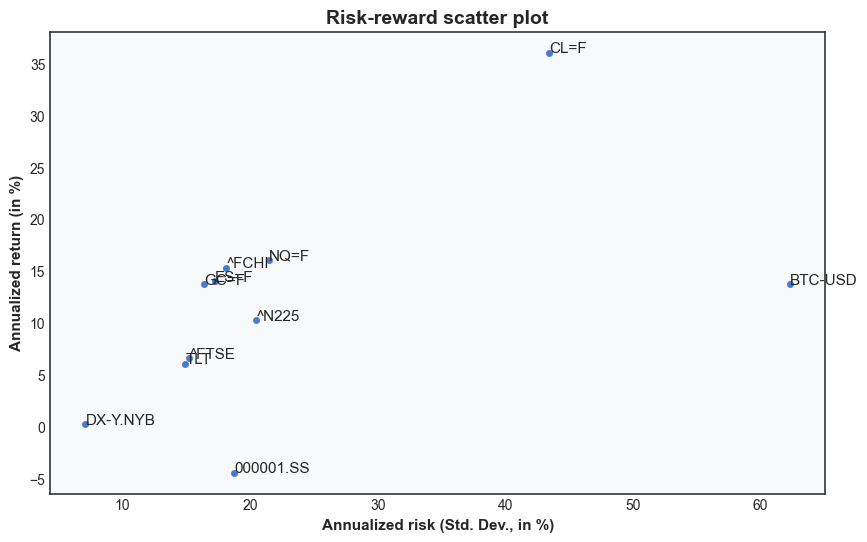

In [104]:
# Risk-Reward scatter plot
risk_reward = pd.DataFrame({
    'Return': log_returns.mean() * TRADING_DAYS * 100, 
    'Risk': log_returns.std() * np.sqrt(TRADING_DAYS) * 100  
})
risk_reward.plot(kind='scatter', x='Risk', y='Return', figsize=(10, 6))
plt.title('Risk-reward scatter plot')
plt.xlabel('Annualized risk (Std. Dev., in %)')
plt.ylabel('Annualized return (in %)')
for i, txt in enumerate(risk_reward.index):
    plt.annotate(txt, (risk_reward['Risk'][i], risk_reward['Return'][i]))

plt.show()

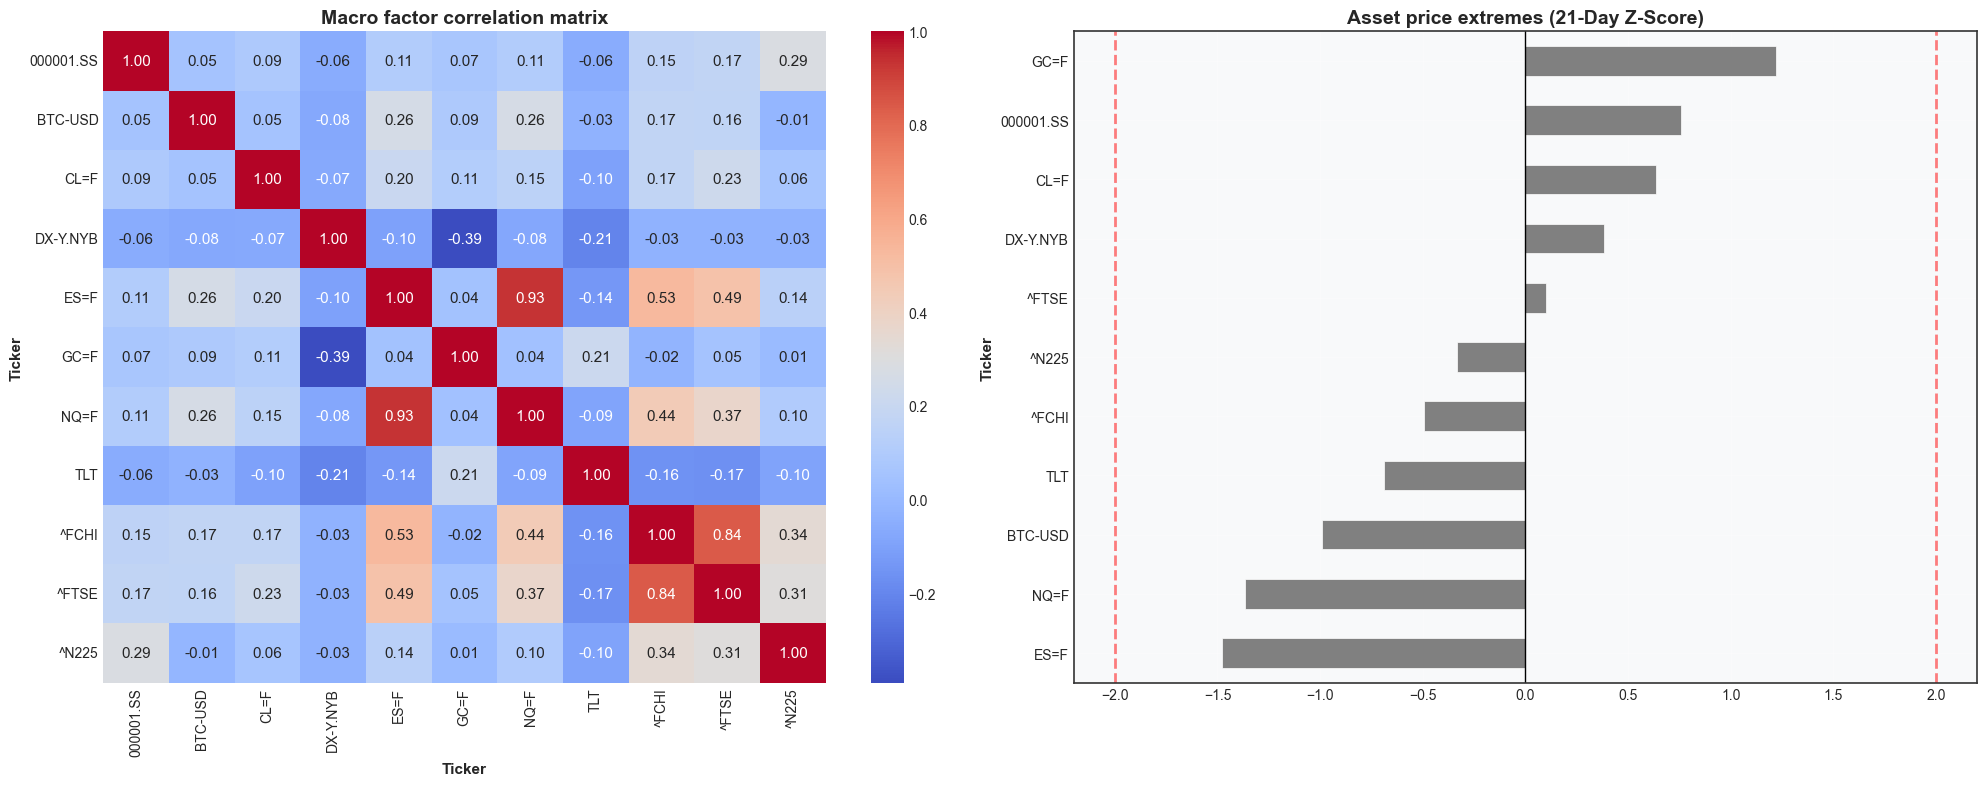

In [105]:
z_scores = (log_returns - log_returns.rolling(window=21).mean()) / log_returns.rolling(window=21).std()
current_z = z_scores.iloc[-1].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
# Pane A: Cross-asset correlation matrix
# Detects if 'Risk-On' and 'Risk-Off' are moving in lockstep (indicates systemic stress)
corr = log_returns.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[0], fmt=".2f")
axes[0].set_title('Macro factor correlation matrix', fontsize=14, fontweight='bold')
    
# Pane B: Z-Score outliers ('signal')
colors = ['red' if x < -2 or x > 2 else 'gray' for x in current_z]
current_z.plot(kind='barh', ax=axes[1], color=colors)
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(2, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(-2, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Asset price extremes (21-Day Z-Score)', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

Static Pearson correlation matrix (daily log returns):


Ticker,000001.SS,BTC-USD,CL=F,DX-Y.NYB,ES=F,GC=F,NQ=F,TLT,^FCHI,^FTSE,^N225
Ticker,,,,,,,,,,,
000001.SS,1.000000,0.052320,0.090530,-0.057149,0.106114,0.066757,0.105714,-0.055075,0.152571,0.171101,0.285719
BTC-USD,0.052320,1.000000,0.049090,-0.075468,0.259965,0.087770,0.262776,-0.029463,0.169982,0.164229,-0.013662
CL=F,0.090530,0.049090,1.000000,-0.066917,0.203842,0.110781,0.147124,-0.101734,0.171451,0.227956,0.064528
DX-Y.NYB,-0.057149,-0.075468,-0.066917,1.000000,-0.100100,-0.391366,-0.076304,-0.207169,-0.028943,-0.031405,-0.029105
ES=F,0.106114,0.259965,0.203842,-0.100100,1.000000,0.043677,0.932536,-0.138977,0.529299,0.486510,0.136745
GC=F,0.066757,0.087770,0.110781,-0.391366,0.043677,1.000000,0.038764,0.212231,-0.023373,0.053453,0.008641
NQ=F,0.105714,0.262776,0.147124,-0.076304,0.932536,0.038764,1.000000,-0.087380,0.443437,0.373723,0.100507
TLT,-0.055075,-0.029463,-0.101734,-0.207169,-0.138977,0.212231,-0.087380,1.000000,-0.157800,-0.167420,-0.097087
^FCHI,0.152571,0.169982,0.171451,-0.028943,0.529299,-0.023373,0.443437,-0.157800,1.000000,0.838453,0.340529


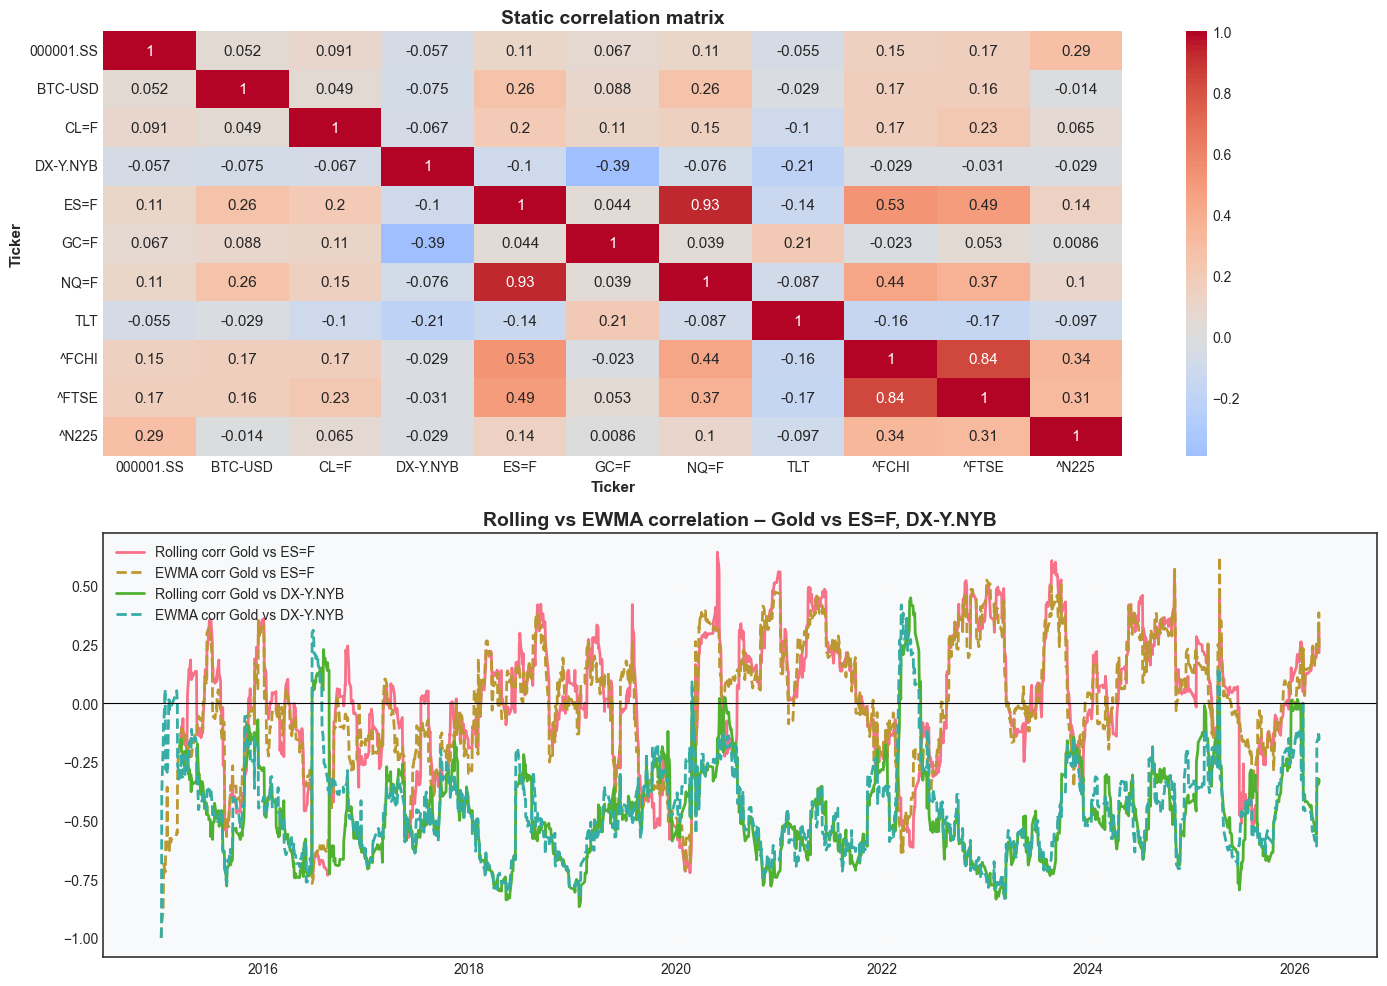

In [106]:
# ---------------------------
# Static correlation
# ---------------------------

corr_matrix = log_returns.corr()

print("Static Pearson correlation matrix (daily log returns):")
display(corr_matrix)

# ---------------------------
# Rolling correlation: Gold vs others
# ---------------------------

rolling_corr = pd.DataFrame(
    index=log_returns.index,
    columns=[t for t in TICKERS if t != GOLD_TICKER and t in log_returns.columns],
    dtype=float
)

for ticker in rolling_corr.columns:
    try:
        rolling_corr[ticker] = log_returns[GOLD_TICKER].rolling(
            window=ROLLING_WINDOW_DAYS
        ).corr(log_returns[ticker])
    except KeyError:
        # Skip tickers that don't exist in log_returns
        rolling_corr.drop(columns=[ticker], inplace=True)

# ---------------------------
# EWMA correlation approximation
# ---------------------------
# We build an exponentially weighted covariance matrix series,
# then convert to correlations for gold vs each asset.

# Use pandas' ewm for exponentially weighted covariance
ewm_cov = log_returns.ewm(alpha=(1 - EWMA_LAMBDA), adjust=False).cov()

# ewm_cov is a MultiIndex (date, ticker); we extract gold row-by-row
# EWMA correlation approximation
ewma_corr_gold = pd.DataFrame(
    index=log_returns.index,
    columns=[t for t in TICKERS if t != GOLD_TICKER and t in log_returns.columns],
    dtype=float
)

for date in log_returns.index:
    try:
        cov_t = ewm_cov.loc[date]
    except KeyError:
        continue

    # Extract variances and covariances
    var_gold = cov_t.loc[GOLD_TICKER, GOLD_TICKER]
    for ticker in ewma_corr_gold.columns:
        if ticker not in cov_t.index:  # Safety check
            continue
        cov_gt = cov_t.loc[GOLD_TICKER, ticker]
        var_t = cov_t.loc[ticker, ticker]
        # Guard against zero variance / NaNs
        if var_gold > 0 and var_t > 0:
            ewma_corr_gold.loc[date, ticker] = cov_gt / np.sqrt(var_gold * var_t)


# ---------------------------
# Visualization: correlation heatmap & Gold vs Key assets
# ---------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Static heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Static correlation matrix")

# Rolling vs EWMA correlation for one or two key assets (e.g., equities & USD)
key_assets = [t for t in ["ES=F", "DX-Y.NYB"] if t in ewma_corr_gold.columns]

for t in key_assets:
    axes[1].plot(
        rolling_corr.index,
        rolling_corr[t],
        label=f"Rolling corr Gold vs {t}"
    )
    axes[1].plot(
        ewma_corr_gold.index,
        ewma_corr_gold[t],
        linestyle="--",
        label=f"EWMA corr Gold vs {t}"
    )

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Rolling vs EWMA correlation – Gold vs {', '.join(key_assets)}")
axes[1].legend()
plt.tight_layout()
plt.show()


In [107]:
def plot_macro_correlation(log_returns, pivot_ticker="GC=F"):
    """
    Enhanced macro correlation analysis using GS Standards.
    """
    GSChartingStandards.configure()
    corr_matrix = log_returns.corr()
    
    # --- 1. Clustered Heatmap (Regime Analysis) ---
    # This automatically groups assets by behavior
    g = sns.clustermap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", # Diverging palette (Blue-Red)
        vmin=-1, vmax=1,
        figsize=(12, 10),
        cbar_pos=(0.02, 0.8, 0.03, 0.15)
    )
    g.fig.suptitle('Macro asset hierarchical clustering', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # --- 2. Masked Heatmap ---
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        center=0,
        linewidths=.5, 
        cbar_kws={"shrink": .8}
    )
    plt.title(f"Macro correlation matrix", loc='left', pad=20)
    plt.show()

    # --- 3. Pivot Correlation (Immediate Insight for Gold) ---
    # Focus only on how the world relates to your primary trade
    gold_corr = corr_matrix[pivot_ticker].sort_values(ascending=False).drop(pivot_ticker)
    
    plt.figure(figsize=(10, 6))
    colors = [GSChartingStandards.COLORS['real'] if x > 0 else GSChartingStandards.COLORS['fail'] for x in gold_corr]
    gold_corr.plot(kind='barh', color=colors)
    
    plt.axvline(0, color='black', lw=1)
    plt.title(f"Asset correlation relative to {pivot_ticker.upper()}", loc='left')
    plt.xlabel("Correlation coefficient")
    plt.grid(axis='x', alpha=0.3)
    plt.show()

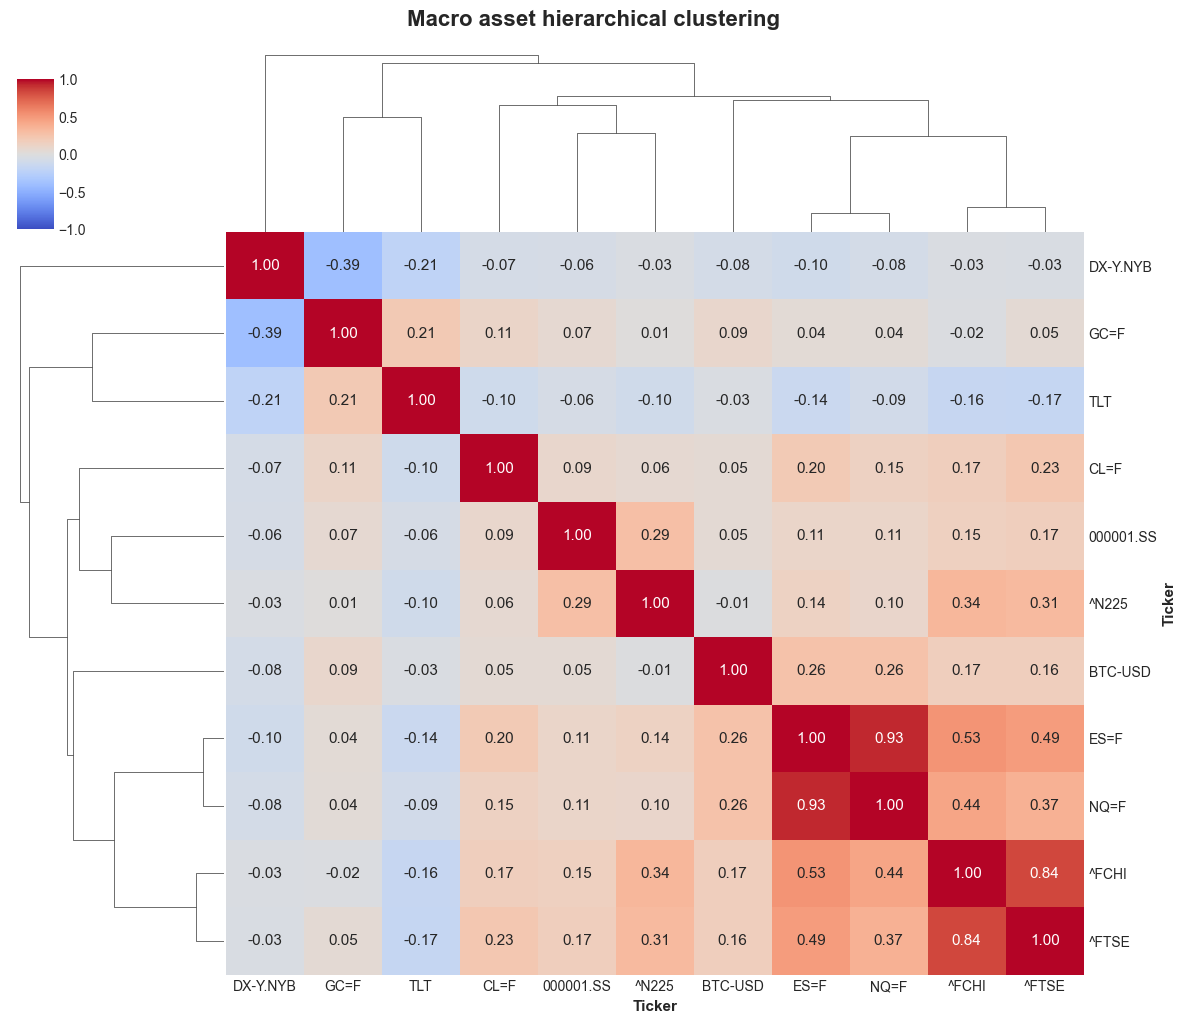

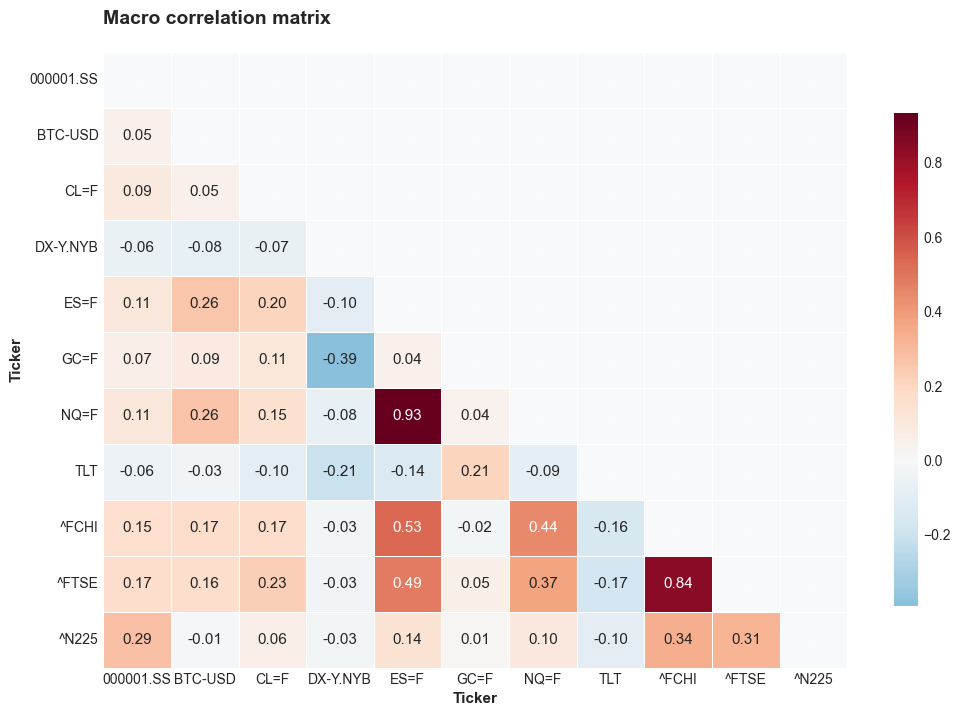

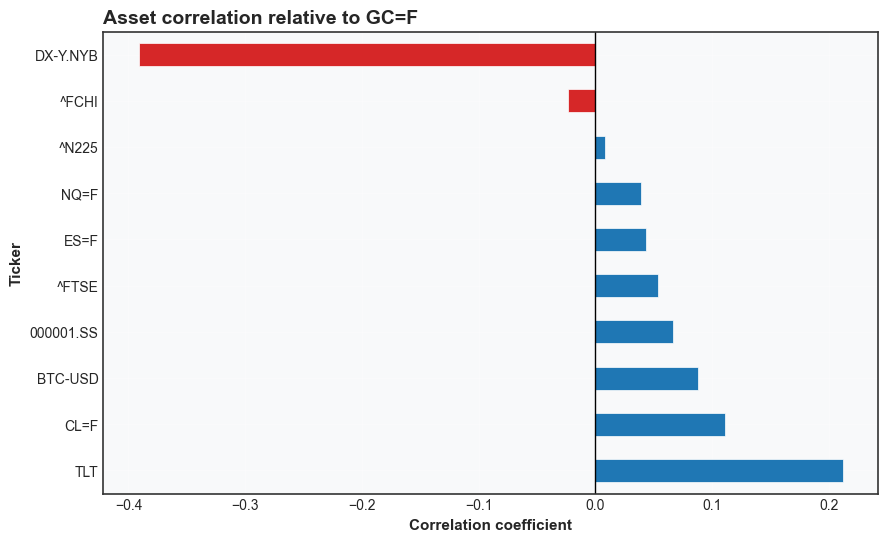

In [108]:
plot_macro_correlation(log_returns)


Correlation analysis - YTD


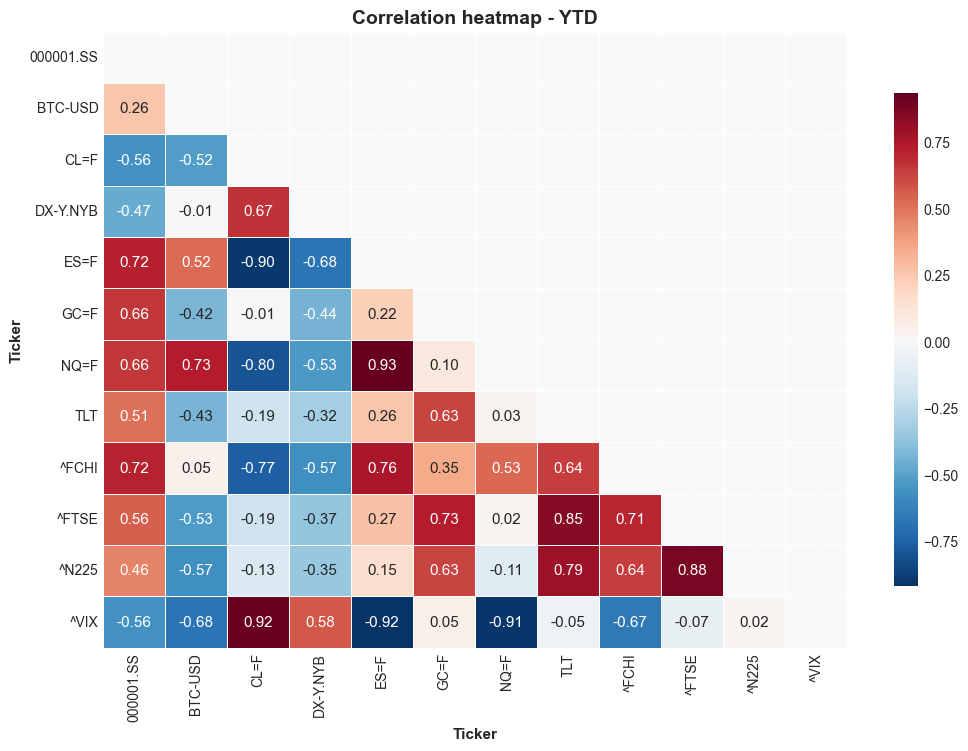


Correlation analysis - 3M


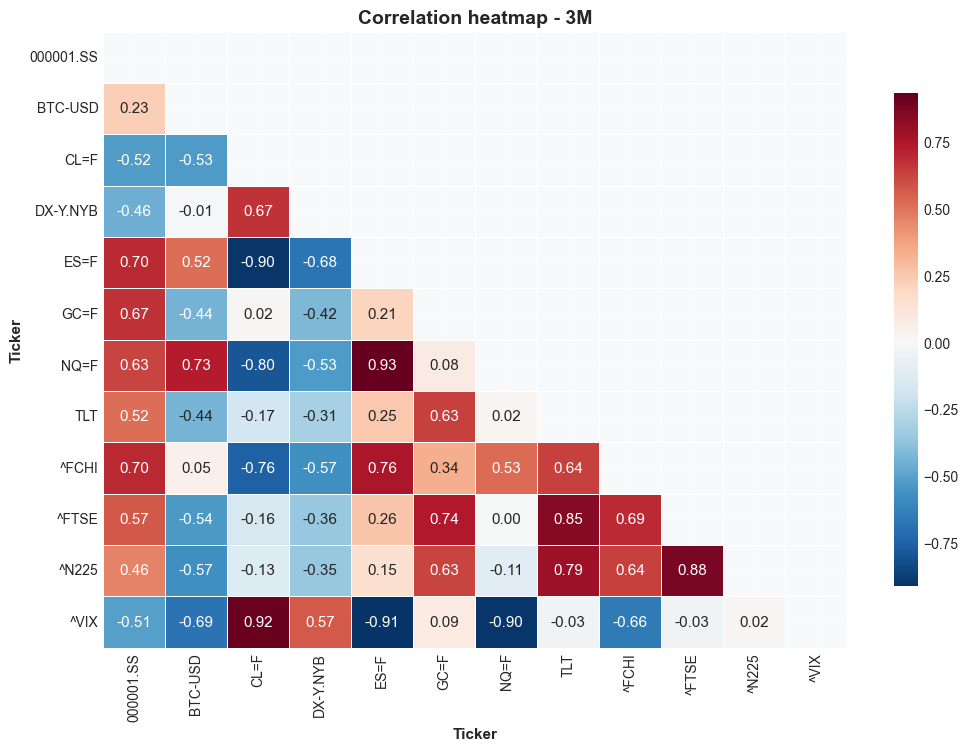


Correlation analysis - 1Y


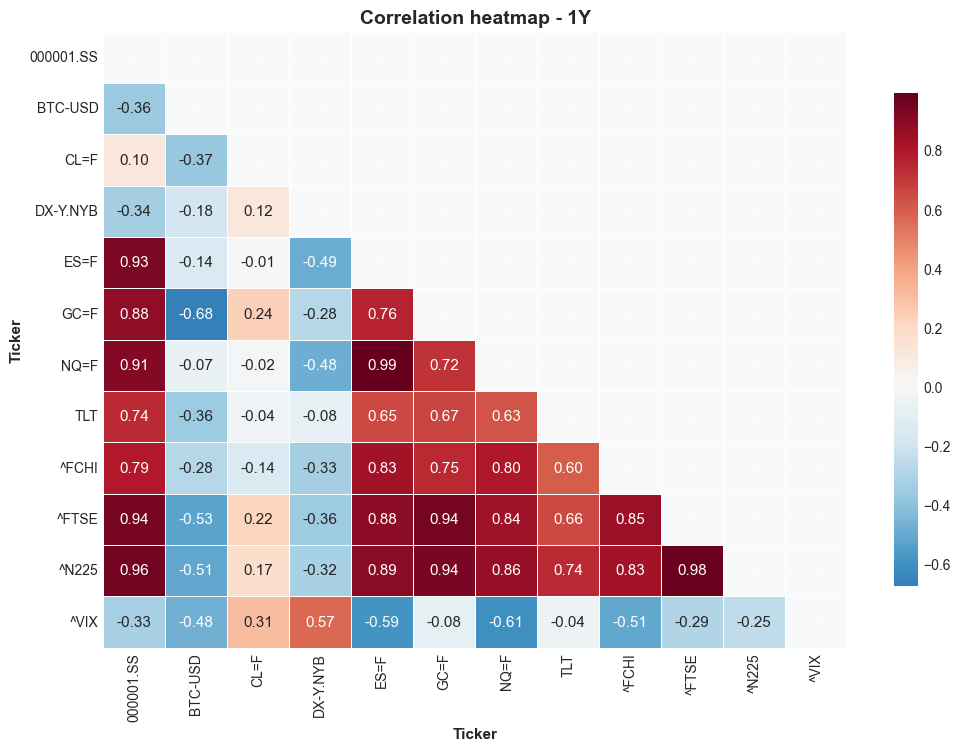


Correlation analysis - Global


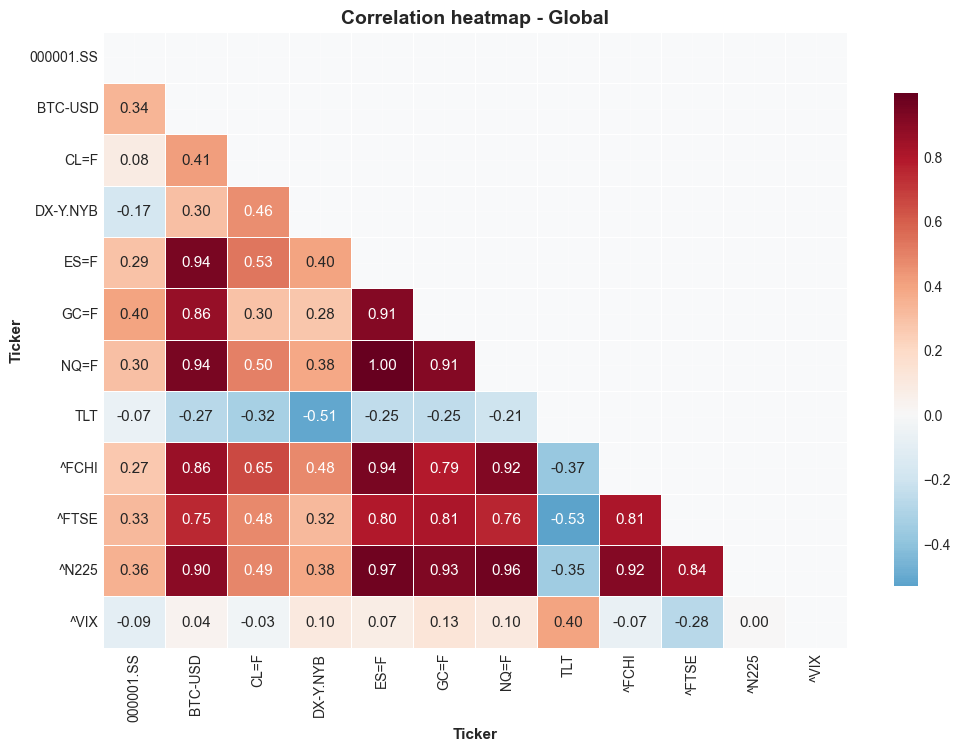

In [109]:
from datetime import datetime

# Function to calculate correlation matrix for a specific period
def calculate_correlation(log_returns, period):
    if period == 'YTD':
        start_date = datetime(datetime.now().year, 1, 1)
    elif period == '3M':
        start_date = datetime.now() - pd.DateOffset(months=3)
    elif period == '1Y':
        start_date = datetime.now() - pd.DateOffset(years=1)
    else:
        start_date = log_returns.index.min()

    filtered_data = log_returns[log_returns.index >= start_date]
    return filtered_data.corr()

# Function to plot correlation heatmap
def plot_correlation_heatmap(corr_matrix, period):
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        center=0,
        linewidths=.5, 
        cbar_kws={"shrink": .8}
    )
    plt.title(f'Correlation heatmap - {period}')
    plt.show()


# Define periods for correlation analysis
periods = ['YTD', '3M', '1Y', 'Global']

# Perform correlation analysis and plot heatmaps
for period in periods:
    print(f"\nCorrelation analysis - {period}")
    corr_matrix = calculate_correlation(close, period)
    plot_correlation_heatmap(corr_matrix, period)


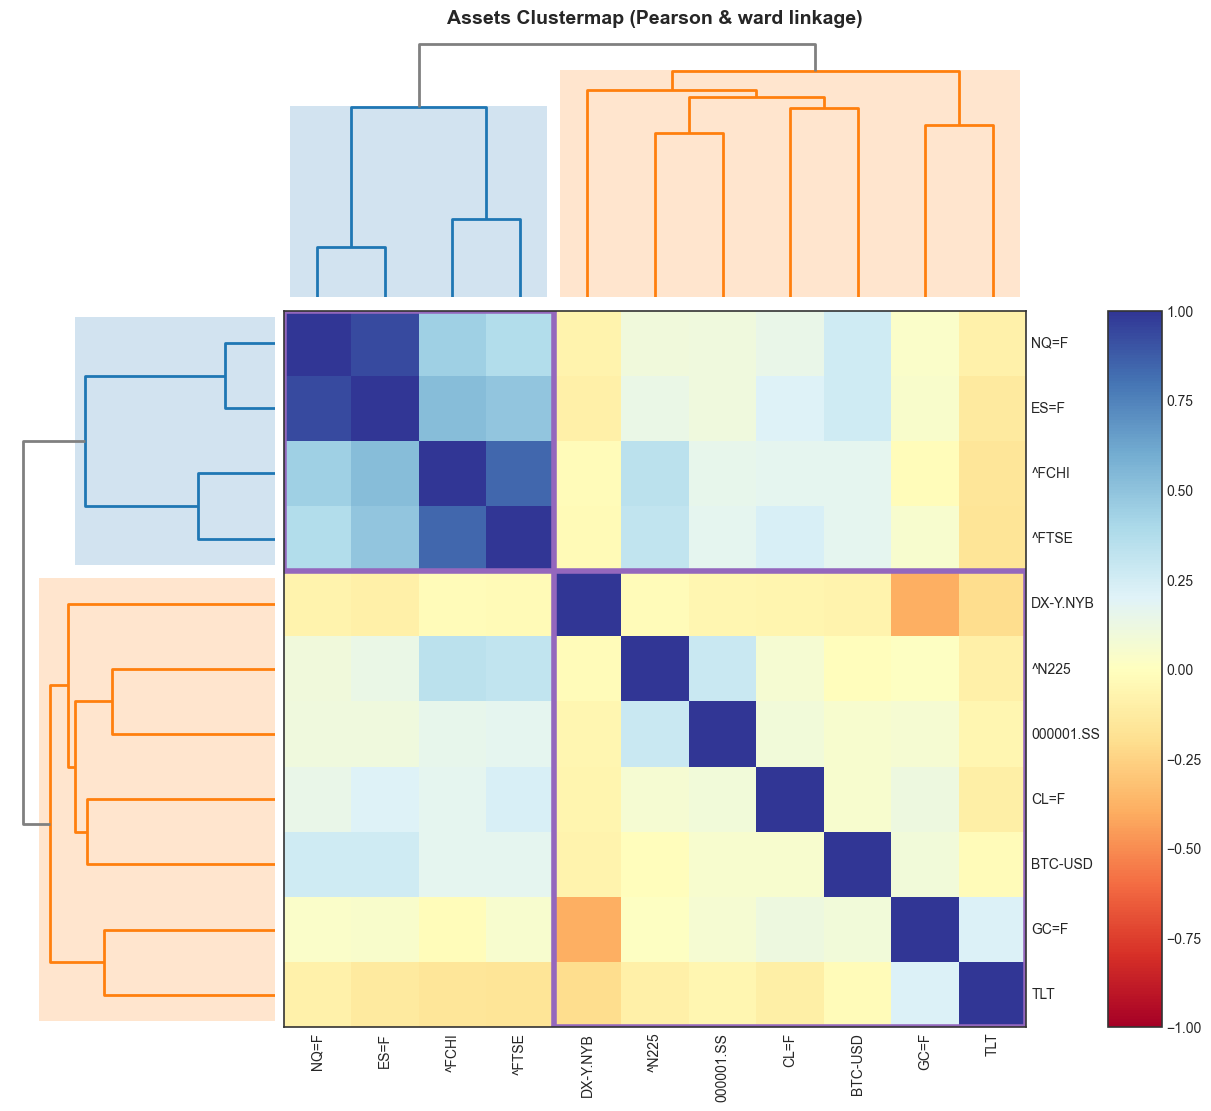

In [110]:
# Plotting assets clusters macro regime detection (HRP clustering)

import riskfolio as rp

ax_HRP_clustering= rp.plot_clusters(returns=log_returns.dropna(),
                      codependence='pearson',
                      linkage='ward',
                      k=None,
                      max_k=10,
                      leaf_order=True,
                      dendrogram=True,
                      linecolor='tab:purple',
                      ax=None)

## Volatility modeling and signal construction
Development of a structured framework for vol estimation (normal, EWMA) and signal construction 

In [111]:
# ---------------------------
# EWMA volatility for Gold
# ---------------------------

# Daily EWMA variance
ewma_var = pd.Series(index=gold_ret.index, dtype=float)
# Initialize with unconditional variance
ewma_var.iloc[0] = gold_ret.var()

for i in range(1, len(gold_ret)):
    r_prev = gold_ret.iloc[i - 1]
    ewma_var.iloc[i] = (
        EWMA_LAMBDA * ewma_var.iloc[i - 1] +
        (1 - EWMA_LAMBDA) * r_prev**2
    )

ewma_vol_daily = np.sqrt(ewma_var)
ewma_vol_annual = ewma_vol_daily * np.sqrt(TRADING_DAYS)

# %%
# ---------------------------
# Underwater curve / Max Drawdown
# ---------------------------

# Cumulative equity curve of 1 unit invested in gold
gold_cum = (1 + gold_ret).cumprod()

# Running peak
running_peak = gold_cum.cummax()

# Drawdown series: percentage drop from peak
drawdown = (gold_cum / running_peak) - 1.0  # negative numbers in drawdown

max_drawdown = drawdown.min()
print(f"Max drawdown over sample: {max_drawdown:.2%}")


Max drawdown over sample: -15.38%


In [112]:
# ---------------------------
# ATR (Average True Range) & vol bands
# ---------------------------

ohlc = gold_ohlc.copy()

# True range
prev_close = ohlc["Close"].shift(1)
tr1 = ohlc["High"] - ohlc["Low"]
tr2 = (ohlc["High"] - prev_close).abs()
tr3 = (ohlc["Low"] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# ATR as simple moving average of true range
atr = true_range.rolling(window=ATR_WINDOW).mean()

# ATR-based volatility bands
upper_band = ohlc["Close"] + ATR_MULTIPLIER * atr
lower_band = ohlc["Close"] - ATR_MULTIPLIER * atr


In [113]:
# ---------------------------
# Rolling Sortino Ratio (Gold)
# ---------------------------

# Helper to compute rolling Sortino
def rolling_sortino(returns, window, trading_days=TRADING_DAYS, rf=0.0):
    """
    Rolling Sortino ratio:
    - returns: daily returns series
    - window: lookback (in days)
    - trading_days: used for annualization
    - rf: daily risk-free rate (approx 0 in most use-cases here)
    """
    sortino = pd.Series(index=returns.index, dtype=float)

    for i in range(window, len(returns)):
        window_slice = returns.iloc[i - window:i]
        # Excess return vs rf (assume rf ~ 0 here)
        excess = window_slice - rf
        mean_excess = excess.mean()

        # Downside deviation: only negative returns
        downside = excess[excess < 0]
        if len(downside) == 0:
            sortino.iloc[i] = np.nan
            continue

        downside_std = downside.std(ddof=0)
        if downside_std == 0:
            sortino.iloc[i] = np.nan
            continue

        # Annualized Sortino
        sortino.iloc[i] = (
            (mean_excess * trading_days) /
            (downside_std * np.sqrt(trading_days))
        )

    return sortino

rolling_sortino_gold = rolling_sortino(gold_ret, window=ROLLING_WINDOW_DAYS)


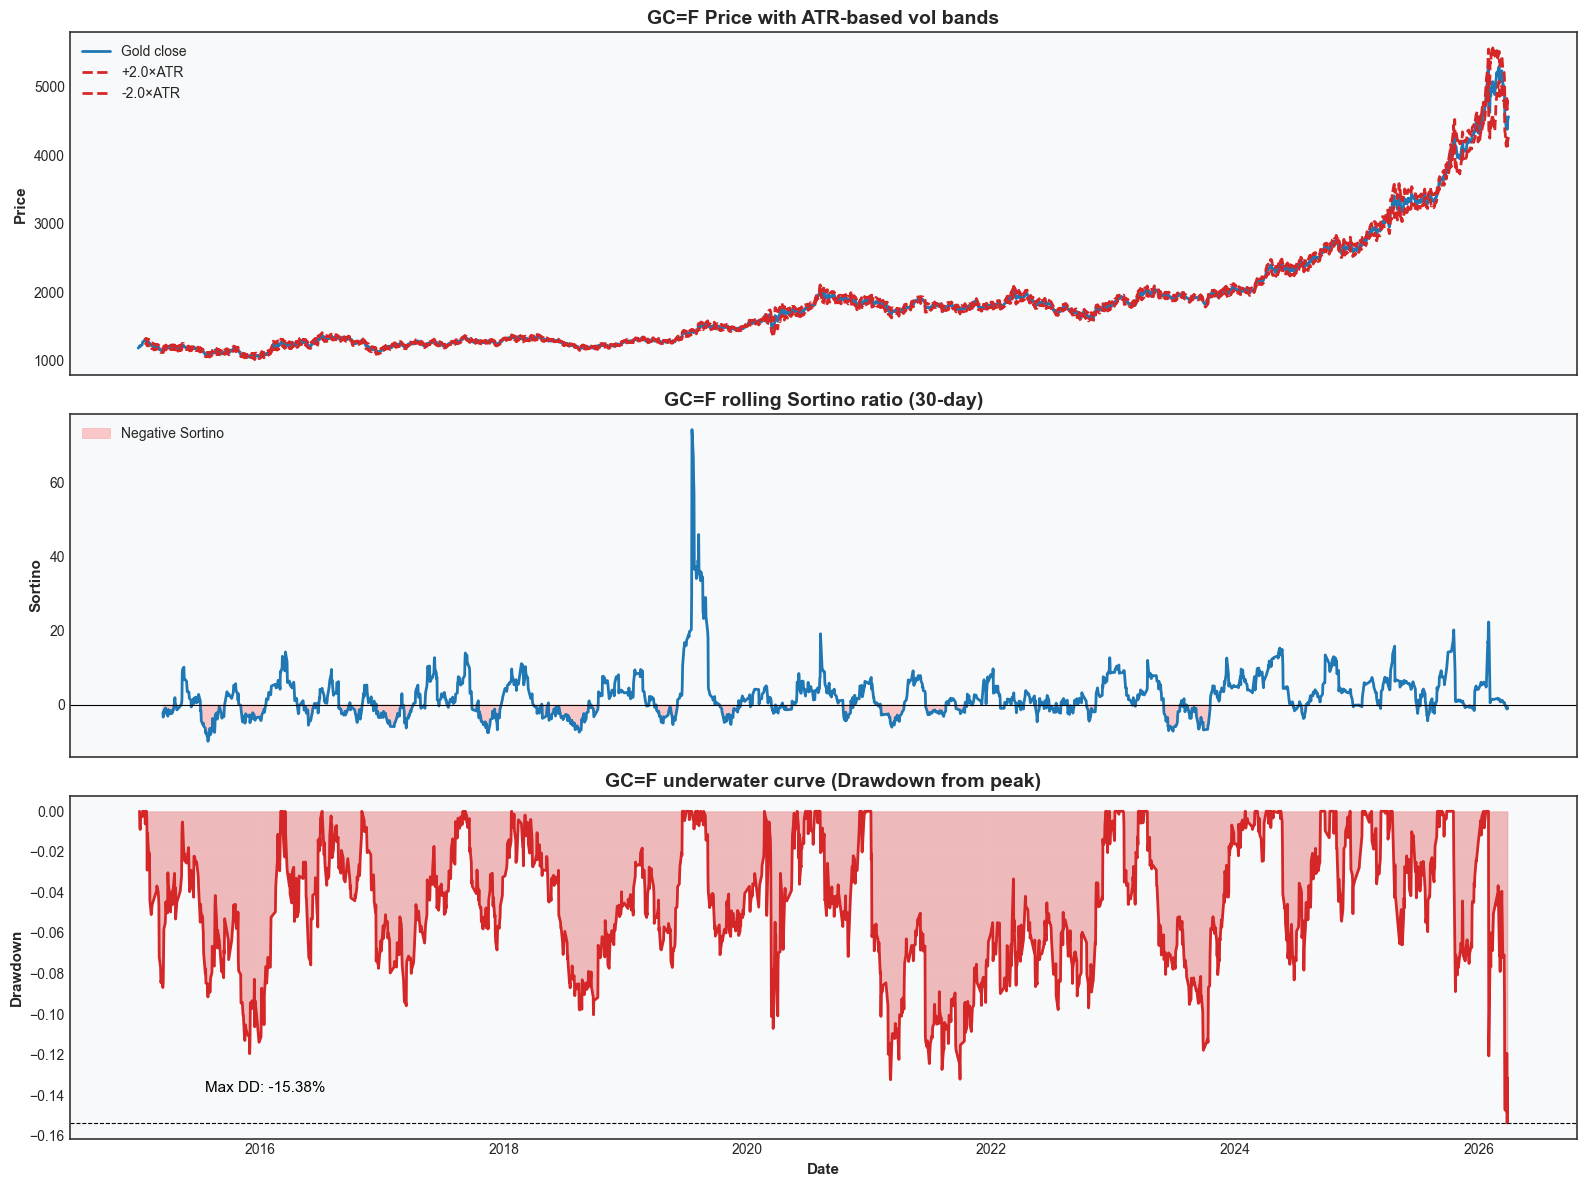

In [114]:
# ---------------------------
# Risk dashboard
# ---------------------------

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- Panel 1: Price + ATR bands ---
axes[0].plot(ohlc.index, ohlc["Close"], label="Gold close", color=GSChartingStandards.COLORS['real'])
axes[0].plot(upper_band.index, upper_band, label=f"+{ATR_MULTIPLIER}×ATR", color=GSChartingStandards.COLORS['fail'], linestyle="--")
axes[0].plot(lower_band.index, lower_band, label=f"-{ATR_MULTIPLIER}×ATR", color=GSChartingStandards.COLORS['fail'], linestyle="--")

axes[0].set_title(f"{GOLD_TICKER} Price with ATR-based vol bands")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# --- Panel 2: Rolling Sortino Ratio ---
axes[1].plot(rolling_sortino_gold.index, rolling_sortino_gold, color=GSChartingStandards.COLORS['real'])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"{GOLD_TICKER} rolling Sortino ratio ({ROLLING_WINDOW_DAYS}-day)")
axes[1].set_ylabel("Sortino")

# Highlight regimes with very poor risk-adjusted performance
axes[1].fill_between(
    rolling_sortino_gold.index,
    rolling_sortino_gold,
    0,
    where=(rolling_sortino_gold < 0),
    color="red",
    alpha=0.2,
    label="Negative Sortino"
)
axes[1].legend(loc="upper left")

# --- Panel 3: Drawdown Curve (Underwater) ---
axes[2].plot(drawdown.index, drawdown, color=GSChartingStandards.COLORS['fail'])
axes[2].fill_between(drawdown.index, drawdown, 0, color=GSChartingStandards.COLORS['fail'], alpha=0.3)
axes[2].set_title(f"{GOLD_TICKER} underwater curve (Drawdown from peak)")
axes[2].set_ylabel("Drawdown")
axes[2].set_xlabel("Date")

# Annotate max drawdown
axes[2].axhline(max_drawdown, color="black", linestyle="--", linewidth=0.8)
axes[2].text(
    x=drawdown.index[int(len(drawdown) * 0.05)],
    y=max_drawdown * 0.9,
    s=f"Max DD: {max_drawdown:.2%}",
    color="black"
)

plt.tight_layout()
plt.show()


In [115]:
# Risk model function encapsulating key metrics for gold CFDs

def build_gold_risk_model(ticker="GC=F", period="20y"):
    """
    Fetches Gold futures data as a proxy for CFDs and calculates institutional risk metrics.
    """
    # 1. Data Ingestion via yfinance
    df = yf.download(ticker, period=period)
    
    # 2. Return Calculation
    df['Returns'] = df['Close'].pct_change()
    
    # 3. Volatility Modeling: Average True Range (ATR)
    # ATR is superior to standard deviation for CFDs as it captures intraday gaps and leverage risks.
    df['High-Low'] = df['High'] - df['Low']
    df['High-PrevClose'] = np.abs(df['High'] - df['Close'].shift(1))
    df['Low-PrevClose'] = np.abs(df['Low'] - df['Close'].shift(1))
    df['TrueRange'] = df[['High-Low', 'High-PrevClose', 'Low-PrevClose']].max(axis=1)
    
    # 14-day rolling ATR
    df['ATR_14'] = df['TrueRange'].rolling(window=14).mean()
    
    # 4. Tail Risk: Value at Risk (VaR) at 95% Confidence
    # Calculates the threshold of the worst expected daily loss
    historical_returns = df['Returns'].dropna()
    var_95 = np.percentile(historical_returns, 5)
    
    # 5. Position Sizing Framework (Fractional Risk)
    # Example: Stop loss placed exactly 2 ATRs away from entry to avoid market noise
    df['Stop_Loss_Distance'] = df['ATR_14'] * 2
    
    # Drop NAs for clean output
    df.dropna(inplace=True)
    
    return df, var_95

# Execute the model
gold_risk_df, gold_var_95 = build_gold_risk_model()

# Display the lean refresh of current risk parameters
print("--- Gold (GC=F) Risk Parameters ---")
print(f"Historical 95% Daily VaR: {gold_var_95:.2%}")
print("\nRecent Market Data & Stop Loss Distances:")
print(gold_risk_df[['Close', 'Returns', 'ATR_14', 'Stop_Loss_Distance']].tail())

[*********************100%***********************]  1 of 1 completed

--- Gold (GC=F) Risk Parameters ---
Historical 95% Daily VaR: -1.81%

Recent Market Data & Stop Loss Distances:
Price             Close   Returns      ATR_14 Stop_Loss_Distance
Ticker             GC=F                                         
Date                                                            
2026-03-24  4399.299805 -0.001090  135.742885         271.485770
2026-03-25  4549.799805  0.034210  138.442906         276.885812
2026-03-26  4375.500000 -0.038309  145.121443         290.242885
2026-03-27  4492.000000  0.026626  147.521449         295.042899
2026-03-30  4561.299805  0.015427  149.557129         299.114258


## Alpha research and signal analysis 
Z-Score and rule based signal strats

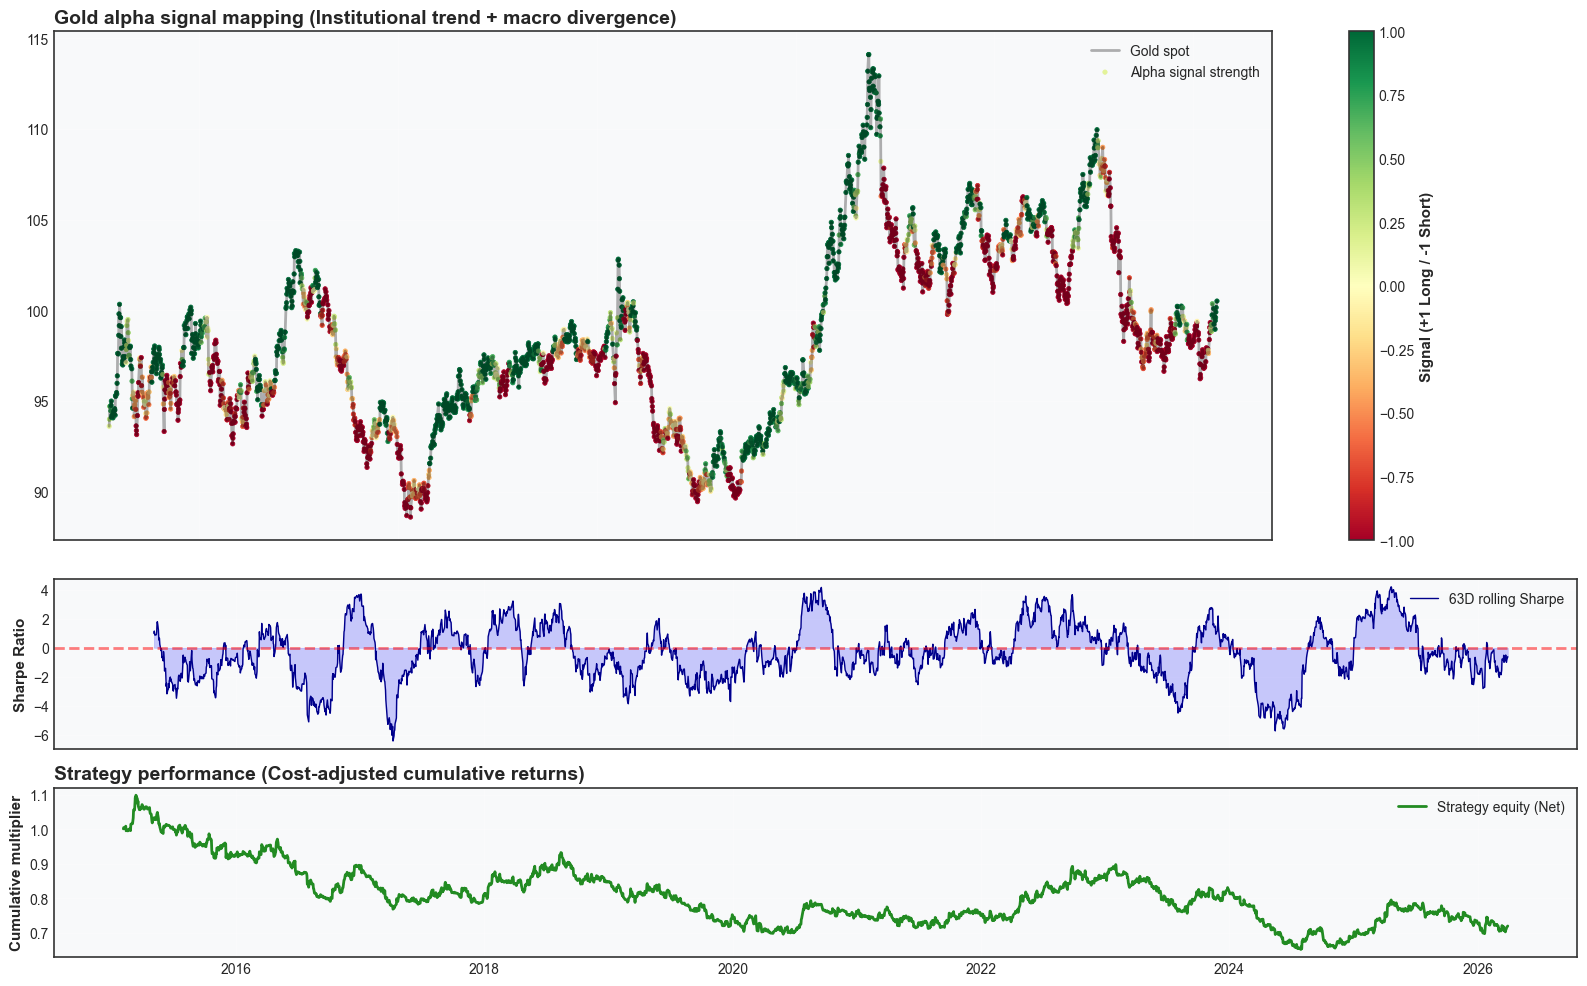

--- QUANT RESEARCH: STRATEGY REPORT ---
Annualized Sharpe Ratio: -0.21
Maximum drawdown:        -40.74%
Final equity multiplier: 0.72x


In [116]:
from scipy.stats import zscore

class GoldAlphaResearch:
    def __init__(self, start_date="2015-01-01"):
        self.tickers = {
            "gold": "GC=F",
            "dxy": "DX-Y.NYB",
            "tlt": "TLT", # Proxy for long-term yields
            "vix": "^VIX"
        }
        self.start_date = start_date
        self.data = None
        self.results = None

    def fetch_data(self):
        """Fetches cross-asset data for alpha modeling"""
        raw = yf.download(list(self.tickers.values()), start=self.start_date, progress=False)['Close']
        raw.columns = [k for k, v in self.tickers.items() if v in raw.columns] or raw.columns
        # Map specific ticker names back to readable keys
        raw = raw.rename(columns={self.tickers[k]: k for k in self.tickers})
        self.data = raw.ffill().dropna()
        return self

    def generate_alpha(self):
        """
        Calculates institutional alpha signals:
        1. Trend alpha (EMA Cross)
        2. Macro divergence alpha (Gold vs DXY inverse correlation)
        """
        df = self.data.copy()
        
        # Returns
        df['ret'] = df['gold'].pct_change()
        
        # --- Signal 1: Momentum (Trend-Following) ---
        fast_ema = df['gold'].ewm(span=20).mean()
        slow_ema = df['gold'].ewm(span=50).mean()
        df['trend_sig'] = np.where(fast_ema > slow_ema, 1, -1)
        
        # --- Signal 2: Macro Divergence (Relative Value) ---
        # Gold usually moves inverse to DXY. If DXY drops and Gold hasn't risen, Alpha is positive.
        df['gold_z'] = zscore(df['gold'].pct_change(20).fillna(0))
        df['dxy_z'] = zscore(df['dxy'].pct_change(20).fillna(0))
        df['macro_sig'] = -df['dxy_z'] # Bet against the dollar
        
        # Combined Alpha Signal (Z-scored)
        df['alpha_composite'] = (df['trend_sig'] + df['macro_sig']).clip(-1, 1)
        
        # --- Volatility Targeting ---
        # Target an annual vol of 12% (standard for commodity carry)
        df['ann_vol'] = df['ret'].rolling(21).std() * np.sqrt(252)
        target_vol = 0.12
        df['leverage'] = (target_vol / df['ann_vol']).shift(1).fillna(0)
        
        self.results = df.dropna()
        return self

    def run_backtest(self, costs_bps=2.0):
        """Vectorized simulation with transaction costs"""
        df = self.results.copy()
        
        # Strategy return = Position * asset return * dynamic leverage
        df['strat_ret_raw'] = df['alpha_composite'].shift(1) * df['ret'] * df['leverage']
        
        # Account for trading costs (spread/slippage) on signal change
        df['turnover'] = (df['alpha_composite'].diff().abs() * df['leverage']).fillna(0)
        df['strat_ret_net'] = df['strat_ret_raw'] - (df['turnover'] * (costs_bps / 10000))
        
        df['cum_ret'] = (1 + df['strat_ret_net']).cumprod()
        df['drawdown'] = df['cum_ret'] / df['cum_ret'].cummax() - 1
        
        self.results = df
        return self

    def plot_dashboard(self):
        """High-fidelity research dashboard"""
        fig, axes = plt.subplots(3, 1, gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)
        
        # 1. Price and Position Density
        axes[0].plot(self.results.index, self.results['gold'], color='black', alpha=0.3, label='Gold spot')
        sc = axes[0].scatter(self.results.index, self.results['gold'], 
                             c=self.results['alpha_composite'], cmap='RdYlGn', s=10, label='Alpha signal strength')
        axes[0].set_title("Gold alpha signal mapping (Institutional trend + macro divergence)", fontsize=14, loc='left')
        plt.colorbar(sc, ax=axes[0], label='Signal (+1 Long / -1 Short)')
        axes[0].legend()

        # 2. Rolling Risk-Adjusted Return
        rolling_sharpe = (self.results['strat_ret_net'].rolling(63).mean() / 
                          self.results['strat_ret_net'].rolling(63).std() * np.sqrt(252))
        axes[1].fill_between(rolling_sharpe.index, rolling_sharpe, 0, alpha=0.2, color='blue')
        axes[1].plot(rolling_sharpe.index, rolling_sharpe, color='darkblue', lw=1, label='63D rolling Sharpe')
        axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
        axes[1].set_ylabel("Sharpe Ratio")
        axes[1].legend()

        # 3. Strategy Equity Curve (Cumulative Net)
        axes[2].plot(self.results.index, self.results['cum_ret'], color='forestgreen', lw=2, label='Strategy equity (Net)')
        axes[2].set_title("Strategy performance (Cost-adjusted cumulative returns)", loc='left')
        axes[2].set_ylabel("Cumulative multiplier")
        axes[2].legend()
        
        plt.tight_layout()
        plt.show()

# --- Execution ---
research = GoldAlphaResearch(start_date="2015-01-01")
research.fetch_data().generate_alpha().run_backtest().plot_dashboard()

# Summary Metrics for the MD
res = research.results['strat_ret_net']
sharpe = (res.mean() / res.std()) * np.sqrt(252)
max_dd = research.results['drawdown'].min()
print(f"--- QUANT RESEARCH: STRATEGY REPORT ---")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Maximum drawdown:        {max_dd*100:.2f}%")
print(f"Final equity multiplier: {research.results['cum_ret'].iloc[-1]:.2f}x")

## Institutional gold alpha framework

In [ ]:
class InstitutionalGoldEngine:
    """
    A Production-Lite Framework for Commodity Quant Trading.
    Focuses on: Alpha Generation, Vol-Targeting, and Transaction Cost Analysis (TCA).
    """
    def __init__(self, ticker="GC=F", capital=5000):
        self.ticker = ticker
        self.initial_capital = capital
        self.data = None
        
    def ingest_and_clean(self):
        # In production, this would be a KDB+ or SQL database connection
        df = yf.download(self.ticker, period="5y", interval="1d")
        df['Returns'] = df['Close'].pct_change()
        self.data = df.dropna()
        return self

    def generate_signals(self):
        """
        Implementation of 'Mean Reversion' Alpha + 'Trend' Filter.
        """
        # Signal A: Bollinger Band Mean Reversion (Z-Score)
        window = 20
        rolling_mean = self.data['Close'].rolling(window=window).mean()
        rolling_std = self.data['Close'].rolling(window=window).std()
        self.data['z_score'] = (self.data['Close'] - rolling_mean) / rolling_std
        
        # Signal B: Trend Filter (Don't trade against the macro trend)
        self.data['trend'] = np.where(self.data['Close'] > self.data['Close'].shift(50), 1, -1)
        
        # Composite Signal
        self.data['signal'] = 0
        self.data.loc[self.data['z_score'] < -2, 'signal'] = 1  # Oversold
        self.data.loc[self.data['z_score'] > 2, 'signal'] = -1  # Overbought
        self.data['signal'] = self.data['signal'] * self.data['trend'] # Filtered
        return self

    def apply_risk_overlay(self):
        """
        Kelly Criterion & Volatility Targeting.
        Ensures we don't 'blow up' like the Telegram signal group.
        """
        # Target 15% Annual Volatility
        target_vol = 0.15 / np.sqrt(252) 
        realized_vol = self.data['Returns'].rolling(20).std()
        
        # Dynamic Position Sizing (Risk Parity)
        self.data['pos_size'] = (target_vol / realized_vol).fillna(0)
        return self

    def backtest_with_tca(self, slippage_bps=1.5):
        """
        Calculates performance subtracting bid-ask spread and market impact.
        """
        self.data['strategy_ret'] = self.data['signal'].shift(1) * self.data['Returns'] * self.data['pos_size']
        
        # Deduct Slippage on every trade (signal change)
        trades = self.data['signal'].diff().abs()
        self.data['net_ret'] = self.data['strategy_ret'] - (trades * (slippage_bps / 10000))
        
        self.data['equity_curve'] = (1 + self.data['net_ret']).cumprod()
        return self.data

# --- Execution ---
engine = InstitutionalGoldEngine()
results = engine.ingest_and_clean().generate_signals().apply_risk_overlay().backtest_with_tca()

print(f"Sharpe ratio: { (results['net_ret'].mean() / results['net_ret'].std()) * np.sqrt(252):.2f}")

[*********************100%***********************]  1 of 1 completed

Final Institutional Sharpe: -0.61


/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


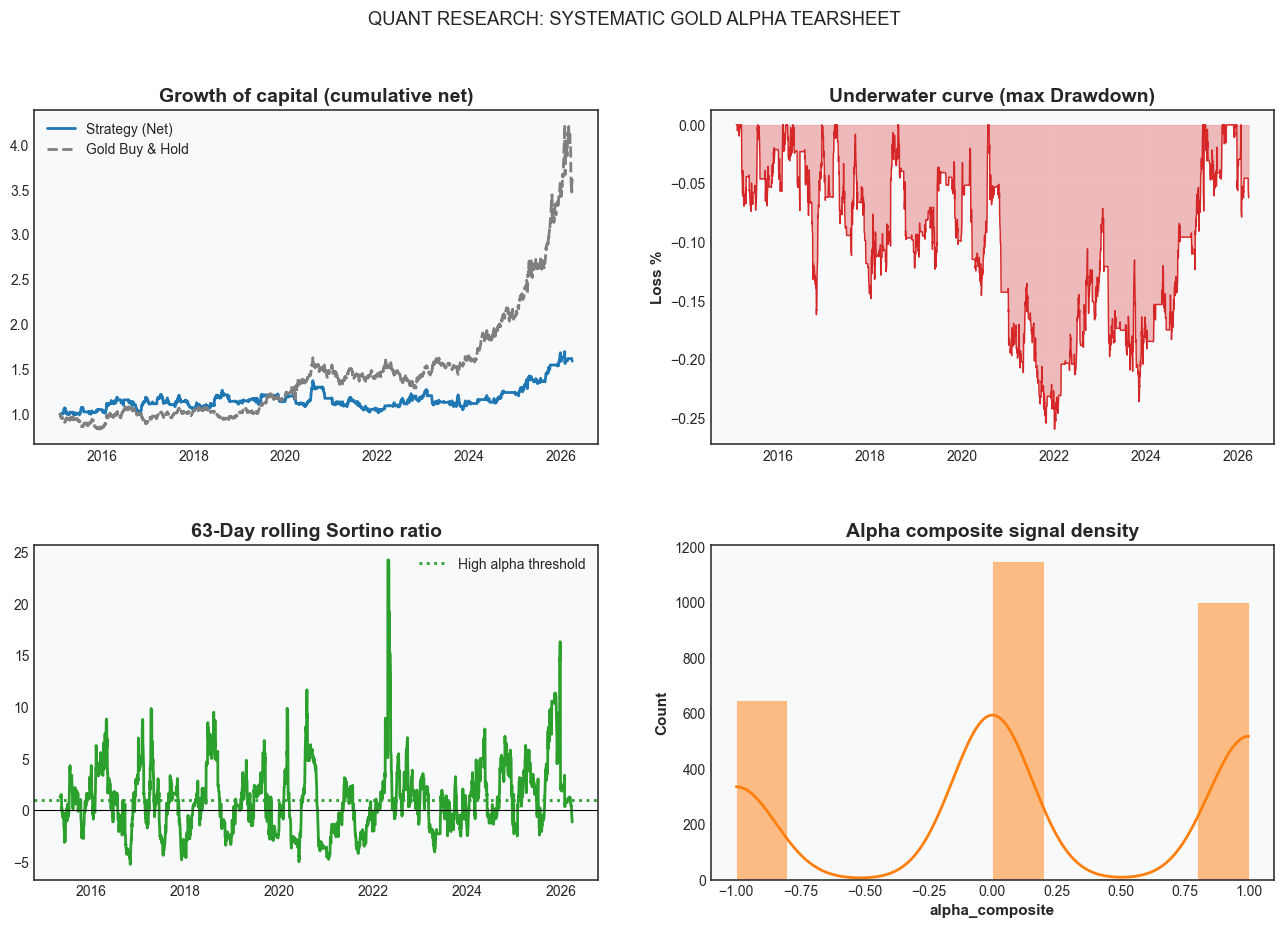

In [118]:
# =============================================================================
# INSTITUTIONAL GOLD ALPHA FRAMEWORK
# =============================================================================
class GoldAlphaResearch:
    def __init__(self, tickers=None, start_date="2018-01-01"):
        # Utilizing user-specified tickers for macro context
        self.tickers = tickers if tickers else {
            "gold": "GC=F",
            "dxy": "DX-Y.NYB",
            "tlt": "TLT",
            "vix": "^VIX"
        }
        self.start_date = start_date
        self.data = None
        self.results = None

    def fetch_and_clean(self):
        """Clean data ingestion leveraging yfinance panel logic"""
        ticker_list = list(self.tickers.values()) if isinstance(self.tickers, dict) else self.tickers
        raw = yf.download(ticker_list, start=self.start_date, progress=False)['Close']
        
        if isinstance(self.tickers, dict):
            # Map back to readable keys
            inv_map = {v: k for k, v in self.tickers.items()}
            raw = raw.rename(columns=inv_map)
            
        self.data = raw.ffill().dropna()
        return self

    def generate_alpha(self):
        """Calculates Dual-Signal Alpha: Trend + Macro Residual"""
        df = self.data.copy()
        df['ret'] = df['gold'].pct_change()
        
        # Signal 1: Exponential Trend (Production Grade)
        df['trend_sig'] = np.where(df['gold'].ewm(span=20).mean() > df['gold'].ewm(span=50).mean(), 1, -1)
        
        # Signal 2: DXY Macro Residual (Gold/Dollar Inverse Correlation)
        df['dxy_ret'] = df['dxy'].pct_change(20)
        df['macro_sig'] = -np.sign(df['dxy_ret']) 
        
        # Composite Signal
        df['alpha_composite'] = ((df['trend_sig'] + df['macro_sig']) / 2).clip(-1, 1)
        
        # Volatility Targeting (15% target for commodity CFD mandate)
        target_vol = 0.15
        df['ann_vol'] = df['ret'].rolling(21).std() * np.sqrt(252)
        df['leverage'] = (target_vol / df['ann_vol']).shift(1).fillna(0)
        
        self.results = df.dropna()
        return self

    def run_backtest(self, costs_bps=2.0):
        """Vectorized simulation with GS cost-awareness"""
        df = self.results.copy()
        df['strat_ret'] = df['alpha_composite'].shift(1) * df['ret'] * df['leverage']
        
        # Deduct transaction costs on turnover
        df['turnover'] = (df['alpha_composite'].diff().abs() * df['leverage']).fillna(0)
        df['net_ret'] = df['strat_ret'] - (df['turnover'] * (costs_bps / 10000))
        
        df['cum_ret'] = (1 + df['net_ret']).cumprod()
        df['drawdown'] = df['cum_ret'] / df['cum_ret'].cummax() - 1
        
        # Downside risk for Sortino calculation
        downside_rets = df['net_ret'].copy()
        downside_rets[downside_rets > 0] = 0
        df['rolling_sortino'] = (df['net_ret'].rolling(63).mean() * 252) / \
                                (downside_rets.rolling(63).std() * np.sqrt(252) + 1e-6)
        
        self.results = df
        return self

    def plot_institutional_tearsheet(self):
        """4-Pane Strategic Dashboard using GS Charting Standards"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        plt.subplots_adjust(hspace=0.3, wspace=0.2)
        
        colors = GSChartingStandards.COLORS
        
        # 1. Performance: Equity Curve
        axes[0, 0].plot(self.results.index, self.results['cum_ret'], color=colors['real'], label='Strategy (Net)')
        benchmark = (1 + self.results['gold'].pct_change().fillna(0)).cumprod()
        axes[0, 0].plot(self.results.index, benchmark, color=colors['neutral'], linestyle='--', label='Gold Buy & Hold')
        axes[0, 0].set_title('Growth of capital (cumulative net)')
        axes[0, 0].legend()

        # 2. Risk: Underwater Drawdown
        axes[0, 1].fill_between(self.results.index, self.results['drawdown'], 0, color=colors['fail'], alpha=0.3)
        axes[0, 1].plot(self.results.index, self.results['drawdown'], color=colors['fail'], lw=1)
        axes[0, 1].set_title('Underwater curve (max Drawdown)')
        axes[0, 1].set_ylabel('Loss %')

        # 3. Alpha Quality: Rolling Sortino
        axes[1, 0].plot(self.results.index, self.results['rolling_sortino'], color=colors['pass'])
        axes[1, 0].axhline(0, color='black', lw=0.8)
        axes[1, 0].axhline(1.0, color=colors['pass'], linestyle=':', label='High alpha threshold')
        axes[1, 0].set_title('63-Day rolling Sortino ratio')
        axes[1, 0].legend()

        # 4. Signal Distribution
        sns.histplot(self.results['alpha_composite'], bins=10, ax=axes[1, 1], color=colors['synthetic'], kde=True)
        axes[1, 1].set_title('Alpha composite signal density')
        
        plt.suptitle("QUANT RESEARCH: SYSTEMATIC GOLD ALPHA TEARSHEET", y=0.98)
        plt.show()

# --- Execution ---
# Define tickers based on the original market analysis
TICKERS = {
    "gold": "GC=F",
    "dxy": "DX-Y.NYB",
    "tlt": "TLT",
    "vix": "^VIX"
}

research = GoldAlphaResearch(tickers=TICKERS, start_date="2015-01-01")
research.fetch_and_clean().generate_alpha().run_backtest().plot_institutional_tearsheet()

In [120]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [121]:
def analyze_factors_pca(log_returns):
        """Identifies the 'Invisible Hand' driving the market regime."""
        # Normalize returns for PCA
        scaled_rets = StandardScaler().fit_transform(log_returns)
        pca = PCA(n_components=5)
        pca.fit(scaled_rets)
        
        # Plot Explained Variance
        plt.figure(figsize=(10, 4))
        plt.bar(range(1, 6), pca.explained_variance_ratio_, color=GSChartingStandards.COLORS['real'])
        plt.title("PCA: Variance explained by macro factors")
        plt.ylabel("Explaining power")
        plt.xlabel("Factor (PC1 = Market mode, PC2 = Dollar/Rate mode)")
        plt.show()
        
        # Loadings for Factor 1 (PC1)
        loadings = pd.Series(pca.components_[0], index=log_returns.columns).sort_values()
        return loadings

def plot_lead_lag(log_returns, leader="DX-Y.NYB", lagger="GC=F", max_lags=10):
        """Detects if 'leader' moves before 'lagger' (Predictive alpha)."""
        corrs = [log_returns[lagger].corr(log_returns[leader].shift(i)) for i in range(-max_lags, max_lags + 1)]
        
        plt.figure(figsize=(12, 5))
        plt.bar(range(-max_lags, max_lags + 1), corrs, color=GSChartingStandards.COLORS['synthetic'])
        plt.axhline(0, color='black', lw=1)
        plt.title(f"Lead-Lag analysis: {leader.upper()} vs {lagger.upper()}")
        plt.xlabel("Lags (Negative = Lagger leads, Positive = Leader leads)")
        plt.ylabel("Correlation strength")
        plt.show()


PCA Loadings: PC1 (the First Principal Component) represents the Global Liquidity Factor. If Gold has a positive loading on PC1 during the "Iran War" regime, it means Gold is trading as a "Risk-On" asset (tracking equities). If it has a negative loading, it is maintaining its "Safe Haven" status.

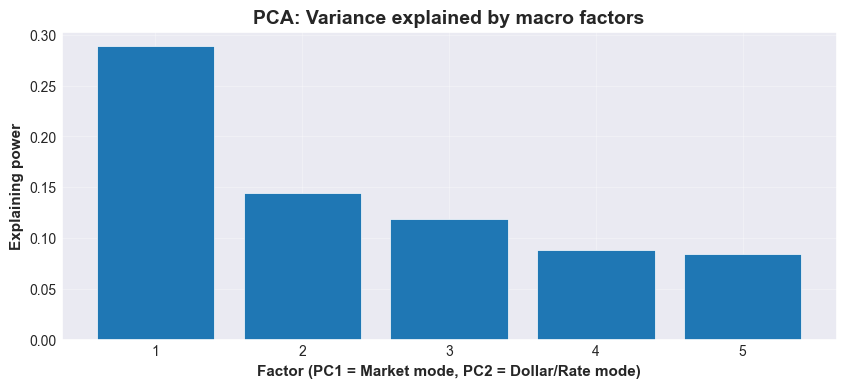

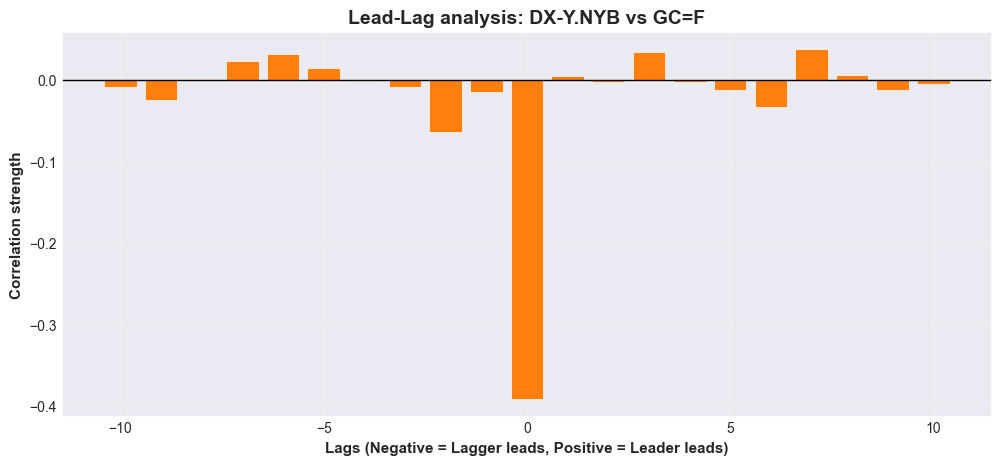

In [122]:
analyze_factors_pca(log_returns)
plot_lead_lag(log_returns, leader="DX-Y.NYB", lagger="GC=F")

In [123]:
def plot_rolling_regime(log_returns, asset_a="GC=F", asset_b="DX-Y.NYB", window=ROLLING_WINDOW_DAYS):
        """Visualizes Regime Shifts (Correlation Breakdown)."""
        rolling_corr = log_returns[asset_a].rolling(window=window).corr(log_returns[asset_b])
        
        plt.figure(figsize=(14, 5))
        plt.plot(rolling_corr, color=GSChartingStandards.COLORS['real'], label=f'{window}D Rolling Correlation')
        plt.axhline(rolling_corr.mean(), color='black', linestyle='--', alpha=0.5, label='Historical Mean')
        plt.fill_between(rolling_corr.index, rolling_corr, rolling_corr.mean(), 
                         where=(rolling_corr < -0.7), color='green', alpha=0.1, label='Strong Inverse Regime')
        plt.fill_between(rolling_corr.index, rolling_corr, rolling_corr.mean(), 
                         where=(rolling_corr > 0), color='red', alpha=0.1, label='Regime Breakdown')
        plt.title(f"Macro regime monitor: {asset_a.upper()} vs {asset_b.upper()}")
        plt.legend()
        plt.show()

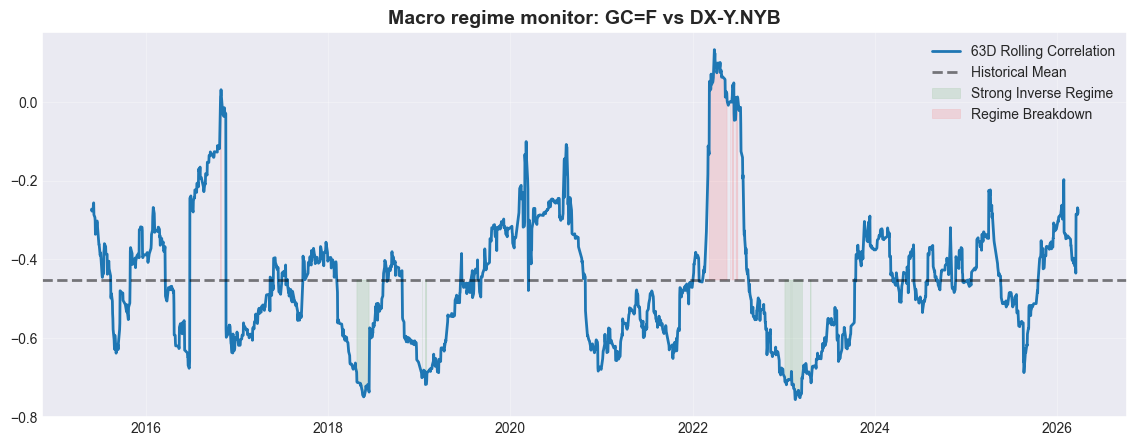

In [ ]:
plot_rolling_regime(log_returns, asset_a="GC=F", asset_b="DX-Y.NYB")